# Equations non-linéaires

**Objectif :** trouver les zéros (ou racines) d'une fonction $f:[a,b] \rightarrow \mathbf R$ : 
$$\alpha \in [a,b] \,:\, f(\alpha) = 0$$

In [7]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt


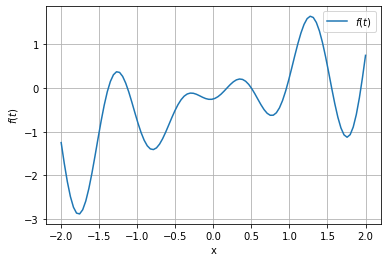

In [20]:
# defining the fonction
def f(x):
    return x*np.sin(x*2.*np.pi) + 0.5*x - 0.25

# f = lambda x : x*np.sin(x*2.*np.pi) + 0.5*x - 0.25

[a,b] = [-2,2]

# points used to plot the graph 
z = np.linspace(a, b, 100)

plt.plot(z, f(z),'-')

# labels, title, legend
plt.xlabel('x'); plt.ylabel('$f(t)$'); #plt.title('data')
plt.legend(['$f(t)$'])
plt.grid(True)
plt.show()

## Méthode de dichotomie ou bissection

Si $f$ est continue et elle change de signe dans $[a,b]$, alors il existe au moins un $\alpha$ tel que $f(\alpha) = 0$.

On peut alors définir l'algorithme suivant :

$a^{(0)}=a$, $b^{(0)}=b$. Pour $k=0,1,...$

1. $x^{(k)}=\frac{a^{(k)}+b^{(k)}}{2}$
2. si $f(x^{(k)})=0$, alors $x^{(k)}$ est le zéro cherché.

    Autrement:

    1. soit $f(x^{(k)})f(a^{(k)})<0$, alors le zéro
    $\alpha\in[a^{(k)},x^{(k)}]$. 

    On pose $a^{(k+1)}=a^{(k)}$ et $b^{(k+1)}=x^{(k)}$

    2. soit $f(x^{(k)}f(b^{(k)})<0$, alors le zéro
    $\alpha\in[x^{(k)},b^{(k)}]$. 

    On pose $a^{(k+1)}=x^{(k)}$ et $b^{(k+1)}=b^{(k)}$


### Exercice
Comprenez et completez la fonction suivante qui effectue l'algorithme de dichotomie 

Ensuite testez-la pour trouver la racine de la fonction $f(x) = x\sin(2\pi x) + \frac12 x - \frac14$ dans l'intervalle $[-1.5,1]$.

In [2]:
def bisection(a,b,fun,tol,maxIterations) :
    # [a,b] interval of interest
    # fun function
    # tolerance desired accuracy
    # maxIterations : maximum number of iteration
    # returns:
    # zero, residual, number of iterations
    
    if (a >= b) :
        print(' b must be greater than a (b > a)')
        return 0,0,0
    
    # what we consider as "zero"
    eps = 1e-12
    
    # evaluate f at the endpoints
    fa = fun(a)
    fb = fun(b)

    if abs(fa) <  eps : # a is the solution
        zero = a
        esterr = fa
        k = 0
        return zero, esterr, k
    
    if abs(fb) <  eps : # b is the solution
        zero = b
        esterr = fb
        k = 0
        return zero, esterr, k

    if fa*fb > 0 :
        print(' The sign of FUN at the extrema of the interval must be different')
        return 0,0,0



    # We want the final error to be smaller than tol, 
    # i.e. k > log( (b-a)/tol ) / log(2)

    nmax = int(np.ceil(np.log( (b-a)/tol ) / np.log(2)))

    
    # but nmax shall be smaller the the nmaximum iterations asked by the user
    if ( maxIterations < nmax ) :
        nmax = int(round(maxIterations))
        print('Warning: nmax is smaller than the minimum number of iterations necessary to reach the tolerance wished');

    # vector of intermadiate approximations etc
    x = np.zeros(nmax)

    # initial error is the length of the interval.
    esterr  = (b - a)

    # do not need to store all the a^k and b^k, so I call them with a new variable name:
    ak = a
    bk = b
    # the values of f at those points are fa and fk

    for k in range(nmax) :

        # approximate solution is midpoint of current interval
        # COMPLETE the code below
        x[k] =  (bk-ak)/2
        fx = fun(x[k])
        
        # error estimator is the half of the previous error
        esterr  = esterr/2

        # COMPLETE the code below

        # if we found the solution, stop the algorithm
        if np.abs(fx) <  eps :
            # error is zero
            zero = x[k]
            esterr = 0
            return  

        if fx*fa < 0  :  # alpha is in (a,x)
            bk = x[k]
        elif fx*fb < 0 : # alpha is in (x,b)
            ak = x[k]
        else  :
            print('Algorithm not operating correctly')



    zero = x[k]

    if esterr > tol :
        print('Warning: bisection stopped without converging to the desired tolerance because the maximum number of iterations was reached')

    return zero, esterr, k, x 


In [10]:
[a,b] = [-.5,1]
tol = 1e-10
maxIter = 4
zero, esterr, k, x = bisection(a,b,f,tol,maxIter)

In [7]:
def plotBisectionIterations (a,b,f,x,N=200) :
    # plot the graphical interpretation of the Bisection method
    import matplotlib.pyplot as plt

    def putSign(y,f,text) :
        if (f(y) < 0) :
            plt.annotate(text, (y, 0.02*deltaAxis) )
        else :
            plt.annotate(text, (y, -0.05*deltaAxis) )
       
    
    z = np.linspace(a,b,N)
    plt.plot(z,f(z), 'b-')
    
    plt.plot([a,a], [0,f(a)], 'g:')
    plt.plot([b,b], [0,f(b)], 'g:')

    # For putting a sign at the initial point
    deltaAxis = plt.gca().axes.get_ylim()[1] - plt.gca().axes.get_ylim()[0]

    putSign(a,f,"a")
    putSign(b,f,"b")
    
    for k in range(x.size) :
        plt.plot([x[k],x[k]], [0, f(x[k])], 'g:')
        putSign(x[k],f,"$x_"+str(k)+"$")

    # Plot the x,y-axis 
    plt.plot([a,b], [0,0], 'k-',linewidth=0.1)
    plt.plot([0,0], [np.min(f(z)),np.max(f(z))], 'k-',linewidth=0.1)

    plt.ylabel('$f$'); plt.xlabel('$x$');

    return

The estimated root is 0.156250000000, the estimated error 9.375e-02 and the residual is -4.196e-02, after 3 iterations


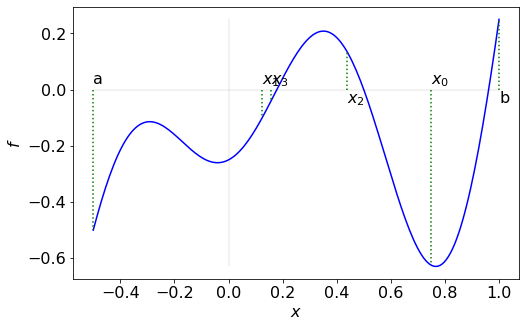

In [11]:
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(8, 5))

plotBisectionIterations(a,b,f,x)

# plt.savefig('Bisection-iterations.png', dpi=600)

print(f'The estimated root is {zero:2.12f}, the estimated error {esterr:1.3e} and the residual is {f(zero):1.3e}, after {k} iterations')